In [1]:
import asyncio
import lsst_efd_client

import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pytz
import sys
from astropy.stats import median_absolute_deviation as mad_astropy
from scipy.stats import binned_statistic
from astropy.time import Time

from lsst.summit.utils import (
    ConsDbClient,
    getAirmassSeeingCorrection,
    getBandpassSeeingCorrection,
)
import os

%matplotlib inline

In [2]:
def biweight_median(sample, CSTD=6.):
    """
    Median with outlier rejection using mad clipping.
    Using the biweight described in Beers 1990 (Used originaly
    for finding galaxy clusters redshfit).

    :param sample: 1d numpy array. The sample where you want
                   to compute the median with outlier rejection.
    :param CSTD:   float. Constant used in the algorithm of the
                   Beers 1990. [default: 6.]
    """
    M = np.median(sample)
    iterate = [copy.deepcopy(M)]
    mu = (sample-M) / (CSTD*mad_astropy(sample))
    Filtre = (abs(mu)<1)
    up = (sample-M) * ((1.-mu**2)**2)
    down = (1.-mu**2)**2
    M += np.sum(up[Filtre])/np.sum(down[Filtre])

    iterate.append(copy.deepcopy(M))
    i = 1
    while abs((iterate[i-1]-iterate[i])/iterate[i])<0.001:
        mu = (sample-M) / (CSTD*mad_astropy(sample))
        Filtre = (abs(mu)<1)
        up = (sample-M) * ((1.-mu**2)**2)
        down = (1.-mu**2)**2
        M += np.sum(up[Filtre])/np.sum(down[Filtre])
        iterate.append(copy.deepcopy(M))
        i += 1
        if i == 100 :
            print('Fail to converge')
            break
    return M

def biweight_mad(sample, CSTD=9.):
    """
    Median absolute deviation with outlier rejection using mad clipping.
    Using the biweight described in Beers 1990 (Used originaly
    for finding galaxy clusters peculiar velocity dispersion).

    :param sample: 1d numpy array. The sample where you want
                   to compute the mad with outlier rejection.
    :param CSTD:   float. Constant used in the algorithm of the
                   Beers 1990. [default: 9.]
    """
    M = biweight_median(sample)
    mu = (sample-M) / (CSTD*mad_astropy(sample))
    Filtre = (abs(mu)<1)
    up = ((sample-M)**2)*((1.-mu**2)**4)
    down = (1.-mu**2)*(1.-5.*mu**2)
    mad = np.sqrt(len(sample)) * (np.sqrt(np.sum(up[Filtre]))/abs(np.sum(down[Filtre])))
    return mad


class meanify1D_wrms():
    """Take data, build a 1d average, and write output average.

    :param bin_spacing: Bin_size, resolution on the mean function. (default=0.3)
    """
    def __init__(self, bin_spacing=0.3):

        self.bin_spacing = bin_spacing

        self.coords = []
        self.params = []
        self.colors = []
        self.params_err = []

    def add_data(self, coord, param, colors=None, params_err=None):
        """
        Add new data to compute the mean function. 

        :param coord: Array of coordinate of the parameter.
        :param param: Array of parameter.
        """
        self.coords.append(coord)
        self.params.append(param)
        self.colors.append(colors)
        if params_err is None:
            self.params_err = None
        else:
            self.params_err.append(params_err)

    def sigma_clipping(self, sigma=3.):
        self.std = []
        nvisits = len(self.params)
        for i in range(nvisits):
            self.std.append(np.std(self.params[i]))
        #mean, std = np.mean(self.std), np.std(self.std)
        mean, std = biweight_median(self.std), biweight_mad(self.std)

        I = 0
        for i in range(nvisits):
            if self.std[i] > mean + sigma * std:
                print('PF:', i)
                del self.params[I]
                if self.params_err is not None:
                    del self.params_err[I]
                del self.coords[I]
            else:
                I+=1
        print('Number of visit removed / nvisits: ',
              nvisits - len(self.params), '/', nvisits)

    def meanify(self, x_min=None, x_max=None):
        """
        Compute the mean function.
        """
        # self.sigma_clipping(sigma=3.)
        params = np.concatenate(self.params)
        coords = np.concatenate(self.coords)
        if self.params_err is not None:
            params_err = np.concatenate(self.params_err)
        else:
            params_err = np.ones_like(params)

        weights = 1./params_err**2

        if x_min is None:
            x_min = np.min(coords)
        if x_max is None:
            x_max = np.max(coords)

        nbin = int((x_max - x_min) / self.bin_spacing) + 1

        binning = np.linspace(x_min, x_max, nbin)
        Filter = np.array([True]*nbin)


        sum_wpp, x0, bin_target = binned_statistic(coords, weights*params*params,
                                                   bins=binning, statistic='sum')

        sum_wp, x0, bin_target = binned_statistic(coords, weights*params,
                                                  bins=binning, statistic='sum')

        sum_w, x0, bin_target = binned_statistic(coords, weights,
                                                 bins=binning, statistic='sum')

        average = sum_wp / sum_w
        wvar = (1. / sum_w) * (sum_wpp - 2.*average*sum_wp + average*average*sum_w)
        wrms = np.sqrt(wvar)

        # get center of each bin 
        x0 = x0[:-1] + (x0[1] - x0[0])/2.

        # remove any entries with nan (counts == 0 and non finite value in
        # the 1D statistic computation) 
        self.x0 = x0
        self.average = average
        self.wrms= wrms

    def save_results(self, name_output='wrms_mag.fits'):
        """
        Write output mean function.
        
        :param name_output: Name of the output fits file. (default: 'mean_gp.fits')
        """
        dtypes = [('X0', self.x0.dtype, self.x0.shape),
                  ('AVERAGE', self.average.dtype, self.average.shape),
                  ('WRMS', self.wrms.dtype, self.wrms.shape),
                  ]
        data = np.empty(1, dtype=dtypes)
        
        data['X0'] = self.x0
        data['AVERAGE'] = self.average
        data['WRMS'] = self.wrms

        with fitsio.FITS(name_output,'rw',clobber=True) as f:
            f.write_table(data, extname='average_solution')

In [3]:
os.environ["no_proxy"] += ",.consdb"
consdb_url = 'http://consdb-pq.consdb:8080/consdb'
cdb_client = ConsDbClient(consdb_url)

In [4]:

query = f"""
SELECT
e.obs_start_mjd,
e.exposure_id,
q.visit_id,
q.guider_e1_mean,
q.guider_e2_mean,
q.guider_altitude_drift,
q.guider_altitude_rms_detrended,
q.guider_altitude_standard_deviation,
q.guider_azimuth_drift,
q.guider_azimuth_rms_detrended,
q.guider_azimuth_standard_deviation,
q.psf_ixx_median,
q.psf_iyy_median,
q.psf_ixy_median
FROM
cdb_lsstcam.visit1_quicklook AS q,
cdb_lsstcam.exposure AS e
WHERE
q.visit_id = e.exposure_id
AND e.img_type = 'science'
AND e.airmass > 0
AND e.band != 'none'
"""

table = cdb_client.query(query).to_pandas()

In [5]:
table['T_median'] = table['psf_ixx_median'] + table['psf_iyy_median']
table['e1_median'] = (table['psf_ixx_median'] - table['psf_iyy_median']) / table['T_median']
table['e2_median'] = 2*table['psf_ixy_median'] / table['T_median']

table['e1_median_un'] = (table['psf_ixx_median'] - table['psf_iyy_median'])
table['e2_median_un'] = 2*table['psf_ixy_median']

/tmp/ipykernel_523/3282668437.py:139: RuntimeWarning: invalid value encountered in divide
  average = sum_wp / sum_w
/tmp/ipykernel_523/3282668437.py:140: RuntimeWarning: divide by zero encountered in divide
  wvar = (1. / sum_w) * (sum_wpp - 2.*average*sum_wp + average*average*sum_w)


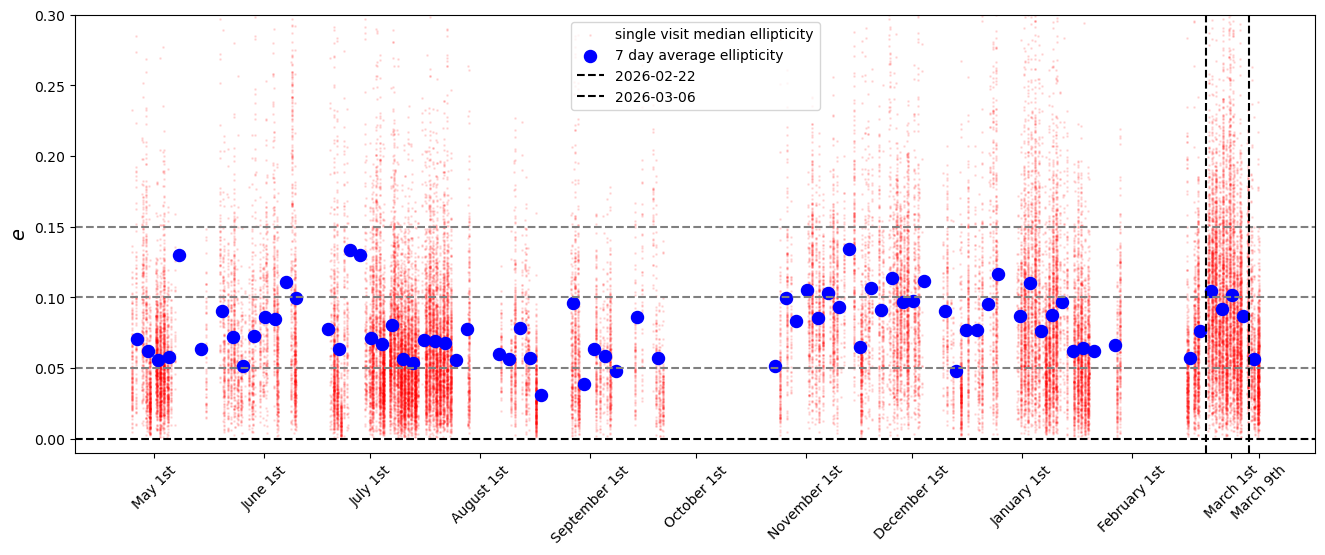

In [8]:
ylabel = '$e$'
key = np.array(table['e2_median']**2 + table['e1_median']**2).astype(float)
key = np.sqrt(key)

x_min = 60500
x_max = 61200
bin_spacing = 3
Filter = np.isfinite(table['obs_start_mjd'])
Filter &= np.isfinite(key)

calendar_date = [
    "May 1st",
    "June 1st",
    "July 1st",
    "August 1st",
    "September 1st",
    "October 1st",
    "November 1st",
    "December 1st",
    "January 1st",
    "February 1st",
    "March 1st",
    "March 9th",
]

mjd_date = [
    Time('2025-05-01 12:00:00', format='iso', scale='utc').mjd,
    Time('2025-06-01 12:00:00', format='iso', scale='utc').mjd,
    Time('2025-07-01 12:00:00', format='iso', scale='utc').mjd,
    Time('2025-08-01 12:00:00', format='iso', scale='utc').mjd,
    Time('2025-09-01 12:00:00', format='iso', scale='utc').mjd,
    Time('2025-10-01 12:00:00', format='iso', scale='utc').mjd,
    Time('2025-11-01 12:00:00', format='iso', scale='utc').mjd,
    Time('2025-12-01 12:00:00', format='iso', scale='utc').mjd,
    Time('2026-01-01 12:00:00', format='iso', scale='utc').mjd,
    Time('2026-02-01 12:00:00', format='iso', scale='utc').mjd,
    Time('2026-03-01 12:00:00', format='iso', scale='utc').mjd,
    Time('2026-03-09 12:00:00', format='iso', scale='utc').mjd,
]

BREAKDATE = Time('2026-02-22 12:00:00', format='iso', scale='utc').mjd
BREAKDATE2 = Time('2026-03-06 12:00:00', format='iso', scale='utc').mjd

meanify = meanify1D_wrms(bin_spacing=bin_spacing)
meanify.add_data(np.array(table['obs_start_mjd'])[Filter],  key[Filter], params_err=None)
meanify.meanify()#x_min=x_min, x_max=x_max)

plt.figure(figsize=(16, 6))
plt.subplots_adjust(bottom=0.15)
plt.scatter(table['obs_start_mjd'], key, c='r', s=1, alpha=0.1, label='single visit median ellipticity')
plt.scatter(meanify.x0, meanify.average, c='b', s=75,label="7 day average ellipticity")
xlim = plt.xlim()
plt.plot(xlim, [0,0], 'k--')
plt.plot(xlim, [0.05,0.05], '--', color='grey')
plt.plot(xlim, [0.10,0.10], '--', color='grey')
plt.plot(xlim, [0.15,0.15], '--', color='grey')



plt.xlim(xlim)
plt.xticks(mjd_date, calendar_date, rotation=45)
ylim = plt.ylim(-0.01,0.3)

plt.plot([BREAKDATE, BREAKDATE], ylim, 'k--', label='2026-02-22')
plt.plot([BREAKDATE2, BREAKDATE2], ylim, 'k--', label='2026-03-06')
plt.ylim(ylim)
_ = plt.ylabel(ylabel, fontsize=14)
plt.legend()
plt.savefig('ellipticity_time_series_v2.png')

In [ ]:
e_cam  = np.array(table['e2_median']).astype(float)

e_guid  = np.array(table['guider_e2_mean']).astype(float)


plt.scatter(e_guid, e_cam, s=10, alpha=0.1, c='b')
xlim = plt.xlim(-0.4, 0.4)
ylim = plt.ylim(-0.4, 0.4)
plt.plot(xlim, [0,0], 'k--')
plt.plot([0,0], ylim, 'k--')
plt.xlabel('e2 guider')
plt.ylabel('e2 visit')
plt.savefig('e2.png')

In [ ]:
Filter  = Time('2025-10-15 12:00:00', format='iso', scale='utc').mjd < table['obs_start_mjd']
Filter &= Time('2025-12-15 12:00:00', format='iso', scale='utc').mjd > table['obs_start_mjd']


e_cam  = np.array(table['e1_median']).astype(float)[~Filter]
e_guid  = np.array(table['guider_e1_mean']).astype(float)[~Filter]


plt.scatter(e_guid, e_cam, s=10, alpha=0.1, c='b')
xlim = plt.xlim(-0.4, 0.4)
ylim = plt.ylim(-0.4, 0.4)
plt.plot(xlim, [0,0], 'k--')
plt.plot([0,0], ylim, 'k--')
plt.xlabel('e1 guider')
plt.ylabel('e1 visit')
plt.savefig('e1_no_november_december.png')

In [ ]:
ylabel = 'FWHM (arcsec)'
key = table['T_median']
key = np.array(key).astype(float)

# Convert PSF sigma to FWHM
sig2fwhm = 2 * np.sqrt(2 * np.log(2))
pixel_scale = 0.2  # arcsec / pixel
key = np.sqrt(key/2) * sig2fwhm * pixel_scale

x_min = 60500
x_max = 61200
bin_spacing = 7
Filter = np.isfinite(table['obs_start_mjd'])
Filter &= np.isfinite(key)

calendar_date = [
    "May 1st",
    "June 1st",
    "July 1st",
    "August 1st",
    "September 1st",
    "October 1st",
    "November 1st",
    "December 1st",
    "January 1st",
    "February 1st",
    "March 1st"
]

mjd_date = [
    Time('2025-05-01 12:00:00', format='iso', scale='utc').mjd,
    Time('2025-06-01 12:00:00', format='iso', scale='utc').mjd,
    Time('2025-07-01 12:00:00', format='iso', scale='utc').mjd,
    Time('2025-08-01 12:00:00', format='iso', scale='utc').mjd,
    Time('2025-09-01 12:00:00', format='iso', scale='utc').mjd,
    Time('2025-10-01 12:00:00', format='iso', scale='utc').mjd,
    Time('2025-11-01 12:00:00', format='iso', scale='utc').mjd,
    Time('2025-12-01 12:00:00', format='iso', scale='utc').mjd,
    Time('2026-01-01 12:00:00', format='iso', scale='utc').mjd,
    Time('2026-02-01 12:00:00', format='iso', scale='utc').mjd,
    Time('2026-03-01 12:00:00', format='iso', scale='utc').mjd,
]


meanify = meanify1D_wrms(bin_spacing=bin_spacing)
meanify.add_data(np.array(table['obs_start_mjd'])[Filter],  key[Filter], params_err=None)
meanify.meanify()#x_min=x_min, x_max=x_max)

plt.figure(figsize=(16, 6))
plt.subplots_adjust(bottom=0.15)
plt.scatter(table['obs_start_mjd'], key, c='r', s=1, alpha=0.1, label='single visit median ellipticity')
plt.scatter(meanify.x0, meanify.average, c='b', s=75,label="7 day average ellipticity")
xlim = plt.xlim()
plt.plot(xlim, [0,0], 'k--')
plt.plot(xlim, [1.5,1.5], '--', color='grey')
plt.plot(xlim, [1.,1.], '--', color='grey')
plt.plot(xlim, [0.8,0.8], '--', color='grey')
plt.xlim(xlim)
plt.xticks(mjd_date, calendar_date, rotation=45)
plt.ylim(-0.01,2)
_ = plt.ylabel(ylabel, fontsize=14)
plt.legend()
plt.savefig('FWHM_time_series_v2.png')

In [ ]:
np.array(table['T_median']).astype(float)